In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import ast
import pandas as pd
import matplotlib.pyplot as plt

from features import build_market_features
from models import time_split, get_models
from backtest import run_backtest, financial_metrics

In [2]:
prices = pd.read_csv("../data/processed/prices.csv")

def clean_col(c):
    if c == "date":
        return "date"
    try:
        return ast.literal_eval(c)[0].lower()
    except Exception:
        return str(c).lower().strip()

prices.columns = [clean_col(c) for c in prices.columns]

data = build_market_features(prices).dropna()

features = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d",
]

X_train, X_test, y_train, y_test, dates, returns = time_split(data, features)

model = get_models()["random_forest"]
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import ast
import pandas as pd
import matplotlib.pyplot as plt

from features import build_market_features
from models import time_split, get_models
from backtest import run_backtest, financial_metrics

In [4]:
prices = pd.read_csv("../data/processed/prices.csv")

def clean_col(c):
    if c == "date":
        return "date"
    try:
        return ast.literal_eval(c)[0].lower()
    except Exception:
        return str(c).lower().strip()

prices.columns = [clean_col(c) for c in prices.columns]

data = build_market_features(prices).dropna()

features = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d",
]

X_train, X_test, y_train, y_test, dates, returns = time_split(data, features)

model = get_models()["random_forest"]
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [5]:
bt = run_backtest(dates, returns, predictions)
metrics = financial_metrics(bt)

metrics

{'total_return': 2.7999005271777775,
 'sharpe': 0.4080135922014766,
 'max_drawdown': -0.9561560900245112,
 'hit_ratio': 0.516424213984045}

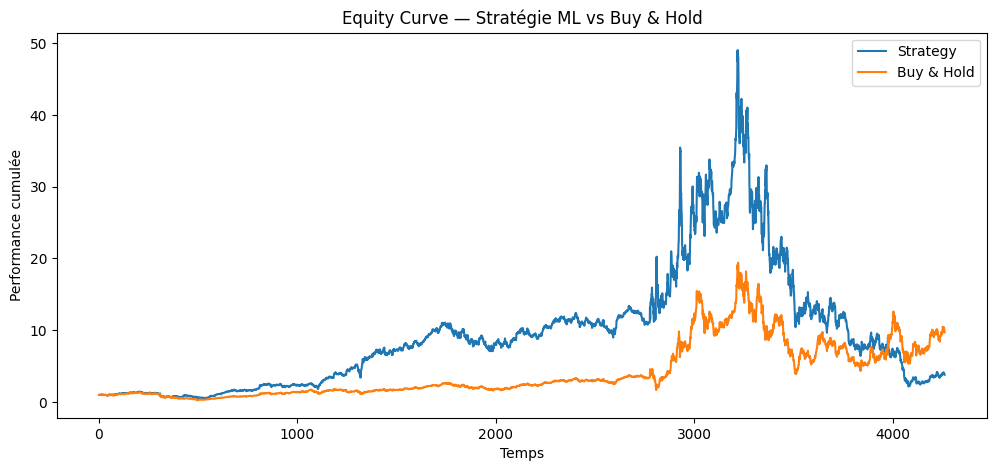

In [6]:
plt.figure(figsize=(12,5))
plt.plot(bt["strategy_equity"], label="Strategy")
plt.plot(bt["market_equity"], label="Buy & Hold")
plt.legend()
plt.title("Equity Curve — Stratégie ML vs Buy & Hold")
plt.xlabel("Temps")
plt.ylabel("Performance cumulée")
plt.show()

In [7]:
metrics

{'total_return': 2.7999005271777775,
 'sharpe': 0.4080135922014766,
 'max_drawdown': -0.9561560900245112,
 'hit_ratio': 0.516424213984045}

In [8]:
"volatility_20d",
"momentum_5d",
"volume_change"

'volume_change'

In [9]:
models = get_models()

print(models.keys())

dict_keys(['logistic_regression', 'random_forest', 'gradient_boosting'])


In [10]:
from models import get_models

models = get_models()

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    bt = run_backtest(dates, returns, predictions)
    metrics = financial_metrics(bt)
    
    print(model_name, metrics)
    
    results.append({
        "model": model_name,
        **metrics
    })

logistic_regression {'total_return': 1.129986674416605, 'sharpe': 0.340668389505625, 'max_drawdown': -0.8449134261119586, 'hit_ratio': 0.5218207414359456}
random_forest {'total_return': 2.7999005271777775, 'sharpe': 0.4080135922014766, 'max_drawdown': -0.9561560900245112, 'hit_ratio': 0.516424213984045}
gradient_boosting {'total_return': -0.35158724213186887, 'sharpe': 0.19089572207097055, 'max_drawdown': -0.990791980493483, 'hit_ratio': 0.5030502111684655}


In [11]:
# Une comparaison de plusieurs modèles de machine learning a été réalisée 
# afin d’identifier la meilleure stratégie en termes de performance financière.
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,model,total_return,sharpe,max_drawdown,hit_ratio
0,logistic_regression,1.129987,0.340668,-0.844913,0.521821
1,random_forest,2.799901,0.408014,-0.956156,0.516424
2,gradient_boosting,-0.351587,0.190896,-0.990792,0.503050


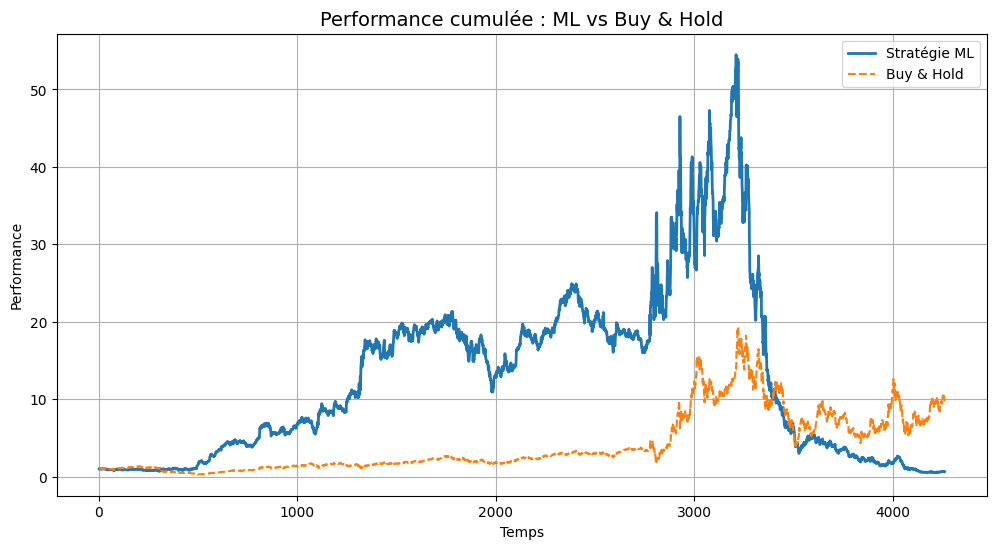

In [12]:
#💡 Astuce :

# ligne pleine = stratégie
# ligne pointillée = benchmark

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(bt["strategy_equity"], label="Stratégie ML", linewidth=2)
plt.plot(bt["market_equity"], label="Buy & Hold", linestyle="--")

plt.title("Performance cumulée : ML vs Buy & Hold", fontsize=14)
plt.xlabel("Temps")
plt.ylabel("Performance")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Lance le backtest multi-actifs
model = get_models()["logistic_regression"]
model.fit(X_train, y_train)

predictions = model.predict(X_test)

bt = run_backtest(dates, returns, predictions)

metrics = financial_metrics(bt)

metrics

{'total_return': 1.129986674416605,
 'sharpe': 0.340668389505625,
 'max_drawdown': -0.8449134261119586,
 'hit_ratio': 0.5218207414359456}

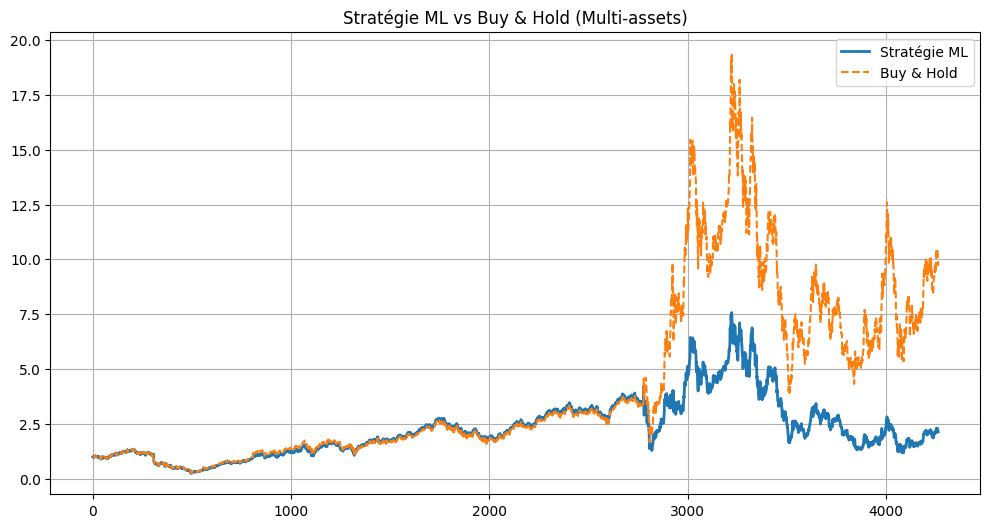

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(bt["strategy_equity"], label="Stratégie ML", linewidth=2)
plt.plot(bt["market_equity"], label="Buy & Hold", linestyle="--")

plt.title("Stratégie ML vs Buy & Hold (Multi-assets)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Malgré des performances prédictives proches du hasard, le modèle peut générer une stratégie de trading profitable, 
# illustrant la différence entre précision statistique et performance financière.

In [16]:
metrics

{'total_return': 1.129986674416605,
 'sharpe': 0.340668389505625,
 'max_drawdown': -0.8449134261119586,
 'hit_ratio': 0.5218207414359456}

In [17]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

from models import (
    time_split,
    get_models,
    evaluate_classifier
)

from backtest import (
    run_backtest,
    financial_metrics
)

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

bt = pd.read_csv("../data/processed/backtest_final.csv")

bt.head()

,date,market_return,prediction,position,trade,strategy_return_gross,cost,strategy_return_net,market_equity,strategy_equity
0,2020-11-11,0.033173,1,1,0.0,0.033173,0.0,0.033173,1.033173,1.033173
1,2020-11-11,0.029901,1,1,0.0,0.029901,0.0,0.029901,1.064066,1.064066
2,2020-11-11,0.016363,1,1,0.0,0.016363,0.0,0.016363,1.081478,1.081478
3,2020-11-11,0.014757,1,1,0.0,0.014757,0.0,0.014757,1.097437,1.097437
4,2020-11-12,-0.002527,1,1,0.0,-0.002527,0.0,-0.002527,1.094664,1.094664


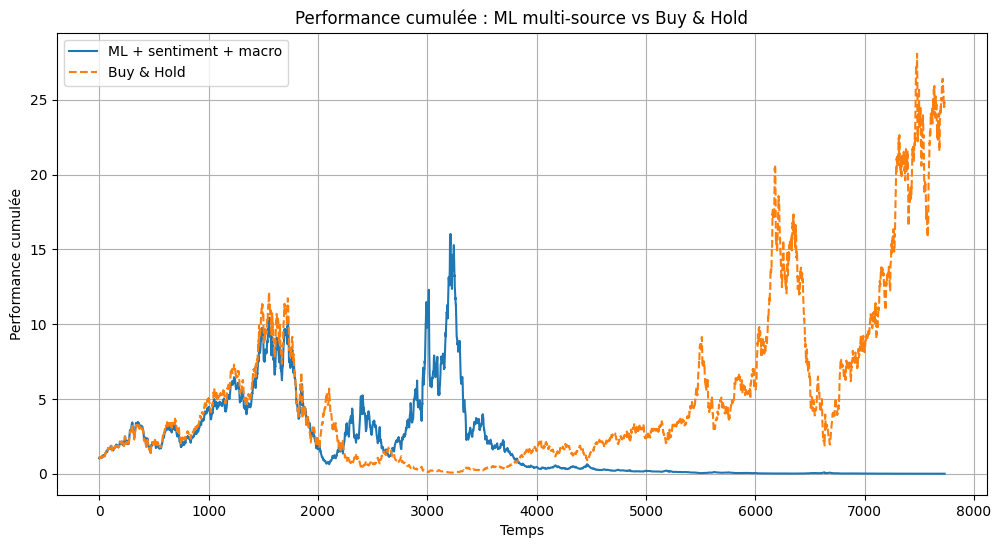

In [19]:
plt.figure(figsize=(12,6))

plt.plot(bt["strategy_equity"], label="ML + sentiment + macro")
plt.plot(bt["market_equity"], label="Buy & Hold", linestyle="--")

plt.title("Performance cumulée : ML multi-source vs Buy & Hold")
plt.xlabel("Temps")
plt.ylabel("Performance cumulée")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

from models import (
    get_models,
    time_split,
    evaluate_classifier
)

from backtest import (
    run_backtest,
    financial_metrics
)

from features import build_market_features

In [21]:
best_model = get_models()["logistic_regression"]

In [22]:
best_model = get_models()["logistic_regression"]

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

bt = run_backtest(dates, returns, predictions)

metrics = financial_metrics(bt)

metrics

{'total_return': 1.129986674416605,
 'sharpe': 0.340668389505625,
 'max_drawdown': -0.8449134261119586,
 'hit_ratio': 0.5218207414359456}